![logo](https://climate.copernicus.eu/sites/default/files/2025-03/logoline_c3s.png)

# Tutorial on retrieving and plotting CARRA2 sea ice area fraction

**Last updated:** 2026-09-04

**This notebook can be run on free online platforms, such as Binder, Kaggle and Colab, or they can be accessed from GitHub. The links to run this notebook in these environments are provided here, but please note they are not supported by ECMWF.**

[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/c3s-training-submodule-reanalysis/develop?labpath=reanalysis-carra2-seaice.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/c3s-training-submodule-reanalysis/blob/develop/reanalysis-carra2-seaice.ipynb)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/c3s-training-submodule-reanalysis/blob/develop/reanalysis-carra2-seaice.ipynb)
[![github](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/ecmwf-training/c3s-training-submodule-reanalysis/blob/develop/reanalysis-carra2-seaice.ipynb)

## Introduction

This tutorial demonstrates how to download and visualise **sea ice area fraction** from the Copernicus pan-Arctic Regional Reanalysis (CARRA2). CARRA2 is the pan-Arctic regional reanalysis, which provides high-resolution (2.5 km) information for a full Arctic domain. In this notebook we will focus on plotting sea ice concentration, however other parameters can be used in a similar fashion. For more details, see the [CARRA2 Product User Guide](https://confluence.ecmwf.int/x/Q6TLIg). The data is freely accessible through the [Copernicus Climate Data Store (CDS)](https://cds.climate.copernicus.eu).

This notebook details two features of CARRA2 dataset as retrieved from CDS:

- **Time-aggregated ("means") data.** Besides the sub-daily analyses and forecasts, CARRA2 is also distributed as **daily** and **monthly** means, extremes and totals. These are served from a dedicated CDS entry, [`reanalysis-pan-carra-means`](https://cds.climate.copernicus.eu/datasets/reanalysis-pan-carra-means). Working with pre-computed means avoids downloading and averaging large volumes of sub-daily data yourself. In this tutorial we use both the **daily** and **monthly** aggregations of this dataset.
- **Sub-domain retrieval.** CDS allows you to request a geographic sub-domain of the full pan-Arctic area. Please note that for CARRA2 sub-domains the number of grid points is the same as for the full domain, but the values outside the requested (latitude, longitude) box are set to missing values. Consequently, the size of the downloaded data file is significantly reduced. This is a convenient way to focus on a region of interest.

In this tutorial we focus on the **sea ice area fraction** because it gives an intuitive picture of where the ice is and how its extent changes through the year. In the second part we retrieve the **2m temperature** alongside it, so that the ice cover can be seen together with the near-surface temperature.

### The annual cycle of Arctic sea ice

Arctic sea ice has a strong seasonal cycle: it reaches its **maximum** extent towards the end of the winter (around March) and its **minimum** extent at the end of the melt season (around September). To give context for the dates chosen in this tutorial, we sample the field close to these seasonal extremes, using the two **equinoxes** (21 March and 21 September) as convenient representative dates.

## Prepare your environment

To make sure this notebook will work, we need to install relevant packages. Furthermore, to download the data directly from CDS, access to the CDSAPI is required.

### Setting up the CDSAPI and your credentials

The code below will ensure that the `cdsapi` package is installed. If you have not set up your `~/.cdsapirc` file with your credentials, you can replace `None` with your credentials that can be found on the [how to api](https://cds.climate.copernicus.eu/how-to-api) page (you will need to log in to see your credentials).

In [ ]:
!pip install -q cdsapi
# If you have already setup your .cdsapirc file you can leave these as None
cdsapi_key = None
cdsapi_url = None

### (Install and) Import libraries

Here we load the relevant libraries for this notebook. To run the code in this tutorial please install any missing packages here.

In [1]:
import os

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cdsapi
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

### Specify data directory

Finally we create folders to store the downloaded data and the plots we produce, so that everything is kept in one place. The folders are only created if they do not already exist.

In [2]:
# Directory to store the downloaded data
DATADIR = "./data/"
# Directory to store the plots
PLOTDIR = "./plots/"

os.makedirs(DATADIR, exist_ok=True)
os.makedirs(PLOTDIR, exist_ok=True)

## Part 1: Daily mean sea ice over the pan-Arctic domain

In this first part we look at the **daily mean** sea ice area fraction over the **full pan-Arctic domain**. We download two dates that are close to the seasonal extremes of the ice cover (the winter maximum in March and the summer minimum in September), so that we can contrast them side by side.

### Download the daily fields

In the section below, daily mean fields for two dates are downloaded and stored. We select the `analysis_based` product of the `reanalysis-pan-carra-means` dataset, the `sea_ice_area_fraction` variable, and the two equinox dates (21 March and 21 September). The data is downloaded in the native GRIB2 format and the resulting file is roughly 5 MB. Note that any of the variables listed in the CDS download form can be requested in the same way.

In [ ]:
daily_path = os.path.join(DATADIR, "sea_ice_area_fraction_daily.grib")

# If you have not setup your .cdsapirc file, you can add url and key within the parenthesis below
client = cdsapi.Client()

dataset = "reanalysis-pan-carra-means"
request = {
    "time_aggregation": "daily",
    "level_type": "single_levels",
    "variable": ["sea_ice_area_fraction"],
    "product_type": "analysis_based",
    "year": ["2025"],
    "month": ["03", "09"],
    "day": ["21"],
    "data_format": "grib",
}

client.retrieve(dataset, request).download(daily_path)

### Load and inspect the dataset

Having downloaded the two dates as a GRIB2 file, we can open it as an `xarray` dataset using the `cfgrib` engine. Printing the dataset lets us inspect the coordinates (`latitude`, `longitude`, `time`) and the available variable. The sea ice area fraction is stored under the short name `siconc`.

In [4]:
ds_daily = xr.open_dataset(daily_path, engine="cfgrib")
ds_daily

<xarray.Dataset> Size: 199MB
Dimensions:     (time: 2, y: 2880, x: 2880)
Coordinates:
  * time        (time) datetime64[ns] 16B 2025-03-21 2025-09-21
    valid_time  (time) datetime64[ns] 16B ...
    latitude    (y, x) float64 66MB ...
    longitude   (y, x) float64 66MB ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    siconc      (time, y, x) float32 66MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             enmi
    GRIB_centreDescription:  Oslo
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Oslo
    history:                 2026-09-04T20:39 GRIB to CDM+CF via cfgrib-0.9.1...

### Plot snapshots of the sea ice maximum and minimum

After inspection, we can now plot the sea ice area fraction for the two dates. The two dates represent, respectively, conditions close to the annual **maximum** (March) and **minimum** (September) of the ice cover. A circular boundary is used to emphasise the extent of the pan-Arctic area, and a single shared colour bar shows the ice fraction from 0 (open water) to 1 (fully ice covered).

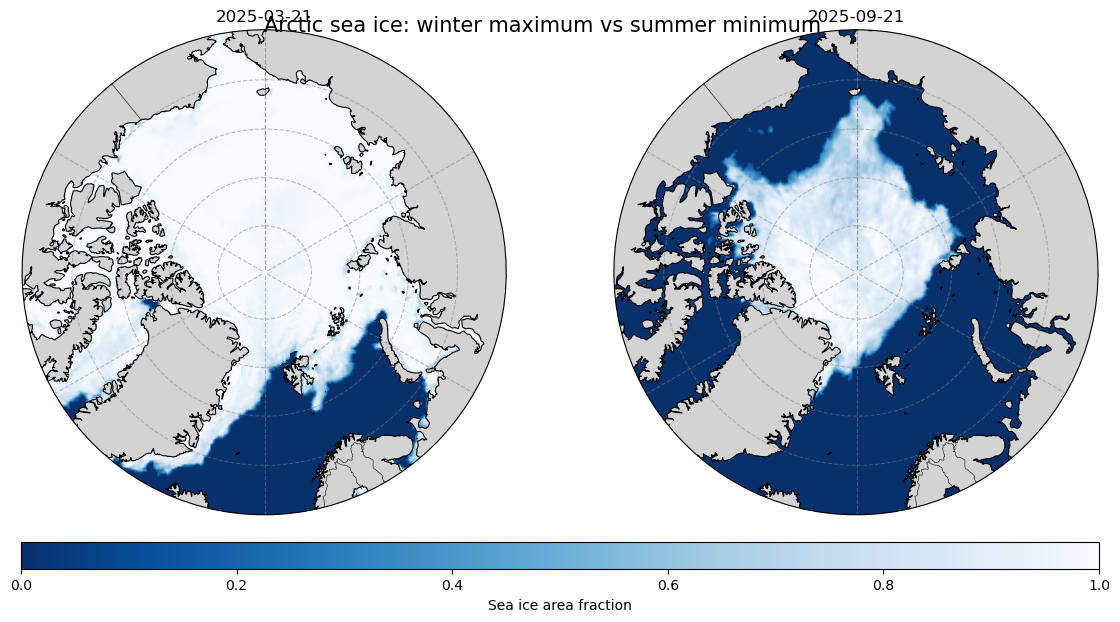

In [7]:
fig, axes = plt.subplots(
    1, 2, figsize=(14, 7), subplot_kw={"projection": ccrs.NorthPolarStereo()}
)

# Define a circular boundary so each map is clipped to a disc
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

for i, ax in enumerate(axes):
    data_slice = ds_daily["siconc"].isel(time=i)

    ax.set_extent([-180, 180, 65, 90], crs=ccrs.PlateCarree())

    im = data_slice.plot.pcolormesh(
        ax=ax,
        x="longitude",
        y="latitude",
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        cmap="Blues_r",
        vmin=0,
        vmax=1,
        zorder=1,
    )

    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)
    ax.gridlines(linestyle="--", color="gray", alpha=0.5, zorder=4)

    ax.set_boundary(circle, transform=ax.transAxes)
    date_str = str(data_slice.time.values)[:10]
    ax.set_title(date_str)

cbar = plt.colorbar(
    im, ax=axes, orientation="horizontal", pad=0.05, fraction=0.05, aspect=40
)
cbar.set_label("Sea ice area fraction")

fig.suptitle(
    "Arctic sea ice: winter maximum vs summer minimum", fontsize=15, y=0.9
)

fig.savefig(
    os.path.join(PLOTDIR, "sea_ice_daily_min_max.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Part 2: Monthly mean sea ice and 2m temperature for a sub-domain

In this second part we demonstrate three further capabilities at once:

- Using the **monthly** aggregation of the `reanalysis-pan-carra-means` dataset.
- Requesting only a geographic **sub-domain** of the full pan-Arctic area.
- Retrieving **two variables in a single request**: the sea ice area fraction together with the 2m temperature.

We choose the **Barents Sea**, the shelf sea between northern Norway, Svalbard and Novaya Zemlya, where the ice edge travels a long way between winter and summer. Downloading a full year of monthly means for this sub-domain then lets us look at how the ice fraction and the near-surface temperature evolve through the year.

### Define your sub-domain

We first define the sub-domain as `[North, West, South, East]`, i.e. the northern and southern latitudes and the western and eastern longitudes of the box. As explained in the introduction, requesting a sub-domain does not change the number of grid points, but sets everything outside the box to missing values, which greatly reduces the downloaded file size.

In [5]:
# Sub-domain covering the Barents Sea: [North, West, South, East]
sub_domain = [80, 15, 70, 60]

### Download the monthly fields for the sub-domain

In the section below we download the **monthly mean** sea ice area fraction and 2m temperature for all twelve months of 2024, restricted to the sub-domain defined above. Note the `area` key in the request, which triggers the sub-domain selection, and that `variable` takes a list, so both fields are delivered in the same GRIB2 file. Because everything outside the box is set to missing values, the resulting file is much smaller than a full pan-Arctic request.

In [ ]:
monthly_path = os.path.join(DATADIR, "sea_ice_and_t2m_monthly_subdomain.grib")

dataset = "reanalysis-pan-carra-means"
request = {
    "time_aggregation": "monthly",
    "level_type": "single_levels",
    "variable": ["sea_ice_area_fraction", "2m_temperature"],
    "product_type": "analysis_based",
    "year": ["2024"],
    "month": [
        "01", "02", "03", "04", "05", "06",
        "07", "08", "09", "10", "11", "12",
    ],
    "data_format": "grib",
    "area": sub_domain,
}

client.retrieve(dataset, request).download(monthly_path)

### Load and inspect the datasets

As before, we open the downloaded GRIB2 file with the `cfgrib` engine. The file now holds two variables on different level types (sea ice at the surface, temperature 2 m above the ground), which cannot be combined into a single `xarray` dataset, so we open the file twice and pick one variable each time with `filter_by_keys`. The keys are the GRIB **short names**: `ci` for the sea ice area fraction (which becomes `siconc` once loaded) and `2t` for the 2m temperature (`t2m`). Both datasets have a `time` dimension holding the twelve monthly means of 2024.

In [ ]:
ds_ice = xr.open_dataset(
    monthly_path,
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"shortName": "ci"}},
)
ds_t2m = xr.open_dataset(
    monthly_path,
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"shortName": "2t"}},
)

# The temperature dataset has the same structure, with t2m in place of siconc
ds_ice

### Plot the data for the sub-domain

We now plot the monthly mean sea ice area fraction for a single month over the sub-domain. Because the values outside the requested box are missing, we simply set the map extent to the sub-domain and the surrounding missing values are not drawn. We add a plot title, keep the latitude/longitude tick labels horizontal so that they do not overlap the map, and use the same blue colour scale as before.

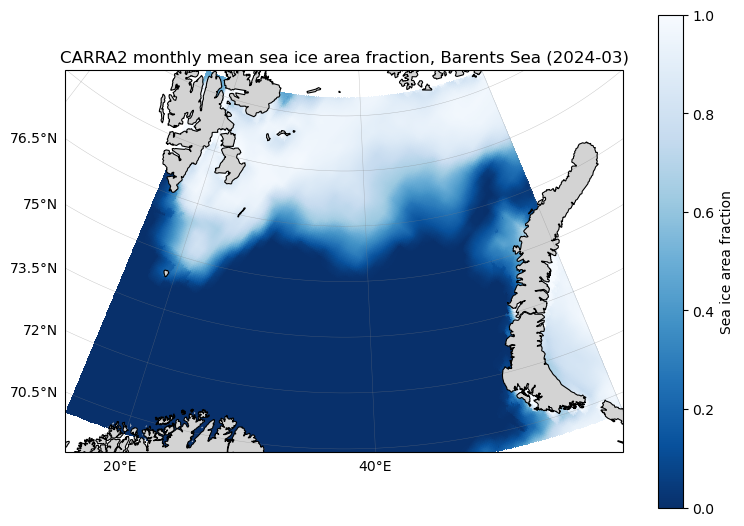

In [8]:
# Choose a month to display (here March, index 2, close to the ice maximum)
month_index = 2
data_slice = ds_ice["siconc"].isel(time=month_index)

N, W, S, E = sub_domain
central_lon = 0.5 * (W + E)
proj = ccrs.NorthPolarStereo(central_longitude=central_lon)

fig = plt.figure(figsize=(9, 8))
ax = plt.axes(projection=proj)
ax.set_extent([W, E, S, N], crs=ccrs.PlateCarree())

im = data_slice.plot.pcolormesh(
    ax=ax,
    x="longitude",
    y="latitude",
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    cmap="Blues_r",
    vmin=0,
    vmax=1,
    zorder=1,
)

ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# Keep the tick labels horizontal and outside the map so they do not overlap it
gl.rotate_labels = False
gl.x_inline = False
gl.y_inline = False

cbar = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.05, shrink=0.8)
cbar.set_label("Sea ice area fraction")

date_str = str(data_slice.time.values)[:7]
ax.set_title(f"CARRA2 monthly mean sea ice area fraction, Barents Sea ({date_str})")

fig.savefig(
    os.path.join(PLOTDIR, "sea_ice_monthly_subdomain.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### Seasonal cycle over the sub-domain

Finally, to add some quantitative context, we summarise the sub-domain with one number per month for each variable: the sea ice area fraction and the 2m temperature, averaged over all valid grid points in the box. Both are shown below, one above the other on a shared month axis, so that the ice cover can be read against the near-surface temperature.

The two curves are deliberately kept in separate panels rather than drawn on a single plot with two y-axes. Ice fraction and temperature have unrelated units, and where two such scales are placed on top of each other the apparent agreement between the curves depends on the limits chosen for the axes rather than on the data.

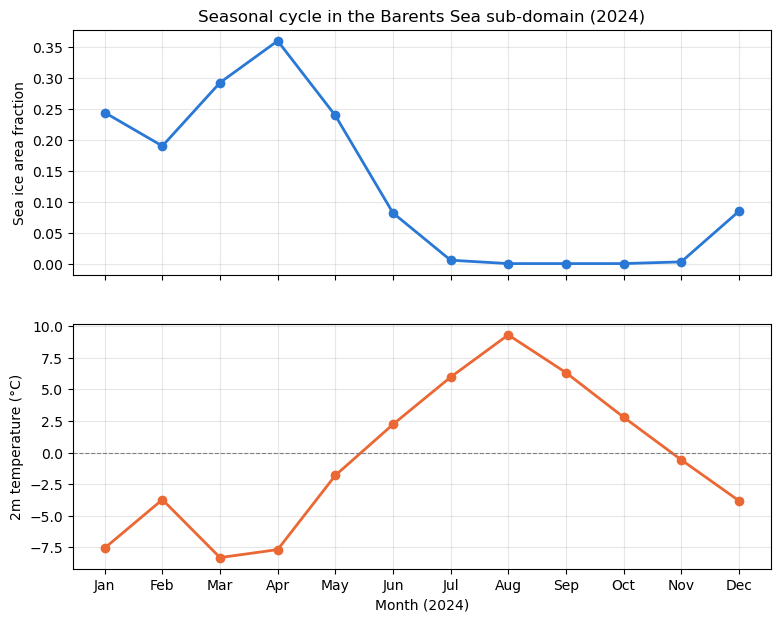

In [9]:
# Average over all valid (non-missing) grid points in the sub-domain
seasonal_siconc = ds_ice["siconc"].mean(dim=["y", "x"], skipna=True)
# CARRA2 temperatures are archived in kelvin, so convert to degrees Celsius
seasonal_t2m = ds_t2m["t2m"].mean(dim=["y", "x"], skipna=True) - 273.15

months = np.arange(1, 13)
month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

fig, (ax_ice, ax_t2m) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax_ice.plot(months, seasonal_siconc.values, marker="o", lw=2, color="#2a78d6")
ax_ice.set_ylabel("Sea ice area fraction")
ax_ice.set_title("Seasonal cycle in the Barents Sea sub-domain (2024)")

ax_t2m.plot(months, seasonal_t2m.values, marker="o", lw=2, color="#eb6834")
# Mark the freezing point, which the temperature curve crosses in spring and autumn
ax_t2m.axhline(0, color="gray", lw=0.8, ls="--")
ax_t2m.set_ylabel("2m temperature (\N{DEGREE SIGN}C)")
ax_t2m.set_xlabel("Month (2024)")
ax_t2m.set_xticks(months)
ax_t2m.set_xticklabels(month_labels)

for ax in (ax_ice, ax_t2m):
    ax.grid(True, alpha=0.3)

fig.savefig(
    os.path.join(PLOTDIR, "sea_ice_t2m_seasonal_cycle.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Summary and going further

In this tutorial you have:

- Downloaded CARRA2 **daily** and **monthly** mean data from the Copernicus Climate Data Store.
- Visualised the sea ice cover over the full **pan-Arctic** domain, contrasting the winter maximum with the summer minimum.
- Requested a geographic **sub-domain** over the Barents Sea, with **two variables** in a single request, saw how this reduces the downloaded file size, and plotted the data for that region.
- Summarised the **seasonal cycle** of the ice fraction and the 2m temperature over the sub-domain.

As a next step you could extend this analysis further, for example by looking at the long-term trends in the March maximum and September minimum over many years, or by comparing the CARRA2 sea ice with an independent satellite observation product such as the [satellite sea ice concentration](https://cds.climate.copernicus.eu/datasets/satellite-sea-ice-concentration) dataset also available on the CDS.